Part 9：Prediction System

In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

G:\Fanshawe College\two semester\6147 pytorch\FlowerClassification_project


In [2]:
project_root = r"G:\Fanshawe College\two semester\6147 pytorch\FlowerClassification_project"

print(os.path.exists(project_root))
print(os.listdir(project_root))

True
['.idea', 'app', 'config.py', 'dataset', 'demo_images', 'Flower Classification Project.docx', 'models', 'notebooks', 'results', 'utils', 'weights', 'World Landmark Recognition and Tourist Information.docx', '__pycache__']


In [3]:
import utils.gradcam
print(utils.gradcam)

from utils.gradcam import GradCAM, show_gradcam

<module 'utils.gradcam' from 'G:\\Fanshawe College\\two semester\\6147 pytorch\\FlowerClassification_project\\utils\\gradcam.py'>


In [4]:
#Top-5 Prediction
import torch

def predict_top5(
    model,
    image_tensor,
    device
):

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor.unsqueeze(0).to(device)
        )

        probs = torch.softmax(outputs, dim=1)

        top_probs, top_ids = torch.topk(
            probs,
            k=5
        )

    return (
        top_ids.squeeze().cpu().numpy(),
        top_probs.squeeze().cpu().numpy()
    )

In [5]:
#Predict image
from PIL import Image

image = Image.open(
    "../demo_images/rose.jpg"
).convert("RGB")

In [6]:
#Transform
from utils.transforms import test_transform

image_tensor = test_transform(image)

In [7]:
from config import DEVICE

In [8]:
#Load EfficientNet
from models.efficientnet import create_efficientnet

model = create_efficientnet()

state_dict = torch.load(
    "../weights/best_efficientnet.pth",
    map_location=DEVICE
)

model.load_state_dict(state_dict)

model.to(DEVICE)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23764\1981750031.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [9]:
#Prediction
from utils.prediction import predict

pred_id, confidence = predict(
    model,
    image_tensor,
    DEVICE
)

print(pred_id)

print(confidence)

20
0.07476748526096344


In [10]:
#Show flower names
from utils.flower_names import ID_TO_NAME

flower_name = ID_TO_NAME[pred_id]

print(flower_name)

Fire Lily


In [11]:
import importlib
import utils.prediction

importlib.reload(utils.prediction)

print(dir(utils.prediction))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'predict', 'predict_top5', 'torch']


In [12]:
from utils.prediction import predict_top5

In [13]:
#Top-5
from utils.prediction import predict_top5

top_ids, top_probs = predict_top5(
    model,
    image_tensor,
    DEVICE
)

from utils.flower_names import ID_TO_NAME

print("=" * 40)

for i in range(5):

    print(
        f"{i+1}. "
        f"{ID_TO_NAME[top_ids[i]]:<30}"
        f"{top_probs[i]*100:.2f}%"
    )

1. Fire Lily                     7.48%
2. Rose                          6.76%
3. Bird of Paradise              3.84%
4. King Protea                   3.73%
5. Anthurium                     3.40%


In [14]:
#Show introduction
from utils.flower_info import FLOWER_INFO

info = FLOWER_INFO.get(
    flower_name.lower(),
    {}
)

print()

print("Flower:")

print(flower_name)

print()

print("Scientific Name:")

print(
    info.get(
        "scientific",
        "Unknown"
    )
)

print()

print("Description:")

print(
    info.get(
        "description",
        "No information available."
    )
)


Flower:
Fire Lily

Scientific Name:
Unknown

Description:
No information available.


In [15]:
from utils.gradcam import GradCAM

cam = GradCAM(
    model,
    model.features[-1]
)

In [32]:
import importlib
import utils.gradcam

importlib.reload(utils.gradcam)

from utils.gradcam import GradCAM, show_gradcam

In [16]:
target_layer = model.features[8][0]

cam = GradCAM(
    model=model,
    target_layer=target_layer
)

In [18]:
x = image_tensor.unsqueeze(0).to(DEVICE)

cam_map = cam.generate(x)

print("CAM shape:", cam_map.shape)
print("CAM min:", cam_map.min())
print("CAM max:", cam_map.max())

CAM shape: (7, 7)
CAM min: 0.0
CAM max: 0.99999857


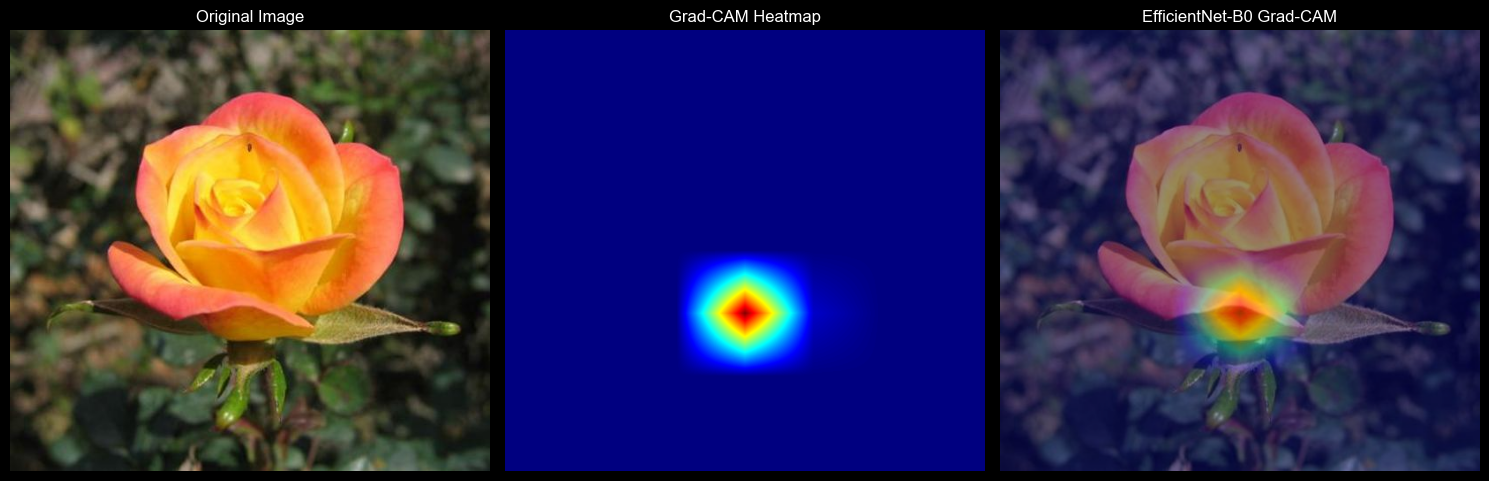

In [34]:
import numpy as np
original_image = np.array(image)

heatmap, overlay = show_gradcam(
    original_image,
    cam_map,
    title="EfficientNet-B0 Grad-CAM"
)

In [35]:
#Heatmap displays
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_gradcam(image, cam):

    cam = cv2.resize(
        cam,
        (image.shape[1], image.shape[0])
    )

    heatmap = cv2.applyColorMap(
        np.uint8(cam * 255),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        0.4 * heatmap +
        0.6 * image
    ).astype(np.uint8)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM")

    plt.show()

In [36]:
for name, module in model.named_modules():
    print(name, type(module))

 <class 'torchvision.models.efficientnet.EfficientNet'>
features <class 'torch.nn.modules.container.Sequential'>
features.0 <class 'torchvision.ops.misc.Conv2dNormActivation'>
features.0.0 <class 'torch.nn.modules.conv.Conv2d'>
features.0.1 <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
features.0.2 <class 'torch.nn.modules.activation.SiLU'>
features.1 <class 'torch.nn.modules.container.Sequential'>
features.1.0 <class 'torchvision.models.efficientnet.MBConv'>
features.1.0.block <class 'torch.nn.modules.container.Sequential'>
features.1.0.block.0 <class 'torchvision.ops.misc.Conv2dNormActivation'>
features.1.0.block.0.0 <class 'torch.nn.modules.conv.Conv2d'>
features.1.0.block.0.1 <class 'torch.nn.modules.batchnorm.BatchNorm2d'>
features.1.0.block.0.2 <class 'torch.nn.modules.activation.SiLU'>
features.1.0.block.1 <class 'torchvision.ops.misc.SqueezeExcitation'>
features.1.0.block.1.avgpool <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>
features.1.0.block.1.fc1 <class 'torch.nn

In [37]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [40]:
from utils.gradcam import GradCAM, show_gradcam

print("Grad-CAM imported successfully!")

Grad-CAM imported successfully!


In [41]:
with torch.no_grad():
    output = model(x)

probabilities = torch.softmax(
    output,
    dim=1
)

pred_idx = probabilities.argmax(
    dim=1
).item()

confidence = probabilities[
    0,
    pred_idx
].item()

from utils.flower_names import ID_TO_NAME

pred_name = ID_TO_NAME[pred_idx]

print("Predicted flower:", pred_name)
print("Confidence:", f"{confidence:.2%}")

Predicted flower: Fire Lily
Confidence: 7.48%


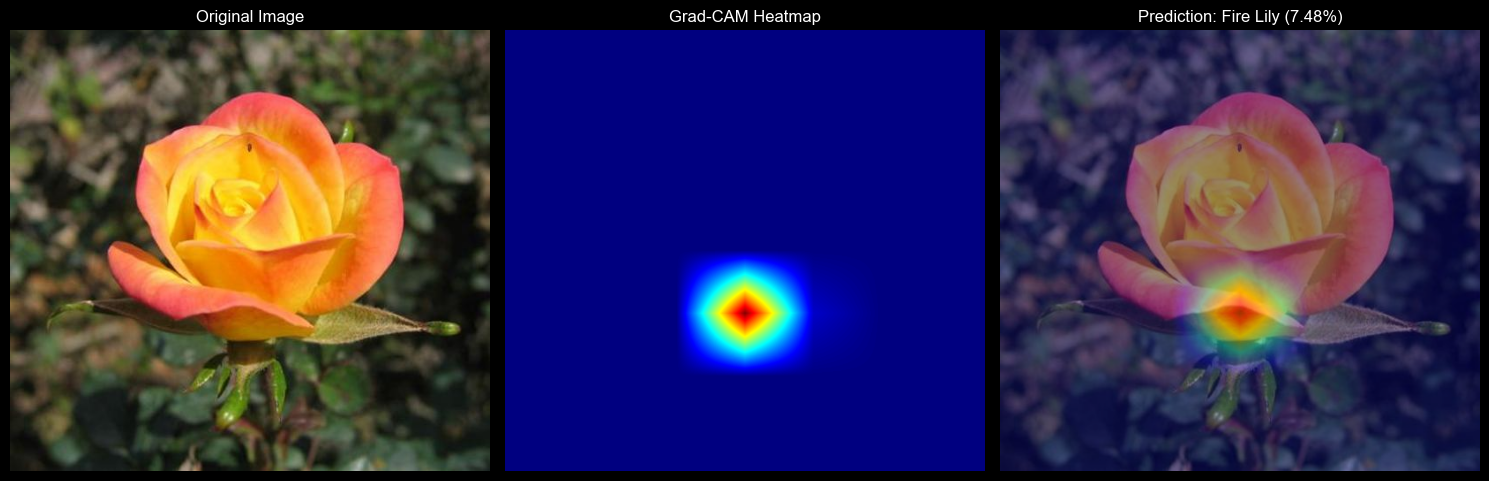

In [42]:
title = (
    f"Prediction: {pred_name} "
    f"({confidence:.2%})"
)

heatmap, overlay = show_gradcam(
    original_image,
    cam_map,
    title=title
)